NNHolo initialized
File is .txt
V_min_coef: 0.01
DV_DDV_min_coef: 1e-05
V0_coef: 0
Vth_min =  -19.512619891336538  at phi =  1.7706770677067707
DVth_min =  -0.036053965138381036
DDVth_min =  -14.962220920700354
V_min_coef: 0.01
DV_DDV_min_coef: 1e-05
V0_coef: 0
Vth_min =  -19.512619891336538  at phi =  1.7706770677067707
DVth_min =  -0.036053965138381036
DDVth_min =  -14.962220920700354


KeyError: 'add_loss'

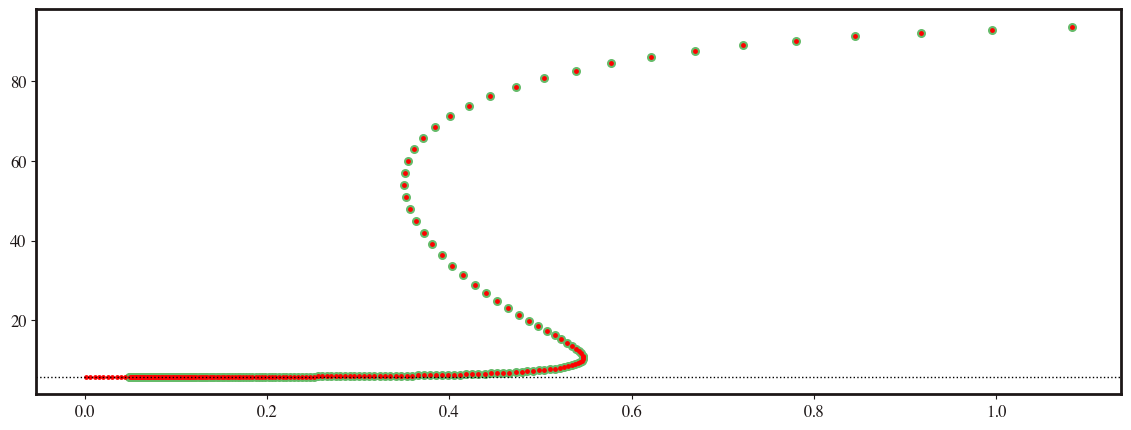

In [ ]:
%run test_0_8_staging_V_DV_DDV_at_min.py

# %run test_0_8_staging_LOAD_RUN.py

tensor(100000.)


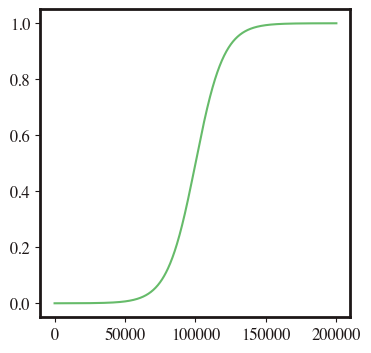

In [2]:
x = torch.linspace(0,200000,1000)
x0 = torch.ones_like(x) * torch.tensor([c.solver.staging_addloss_epoch])   # Epoch at which loss starts gaining weight

x0 = torch.ones_like(x) * torch.tensor([100000])
print(x0[1])

a = 1e-4     # Slope of the tanh function for the staging

y = torch.sigmoid(a*(x - x0))

plt.plot(x, y.detach().numpy())


### Visualize results

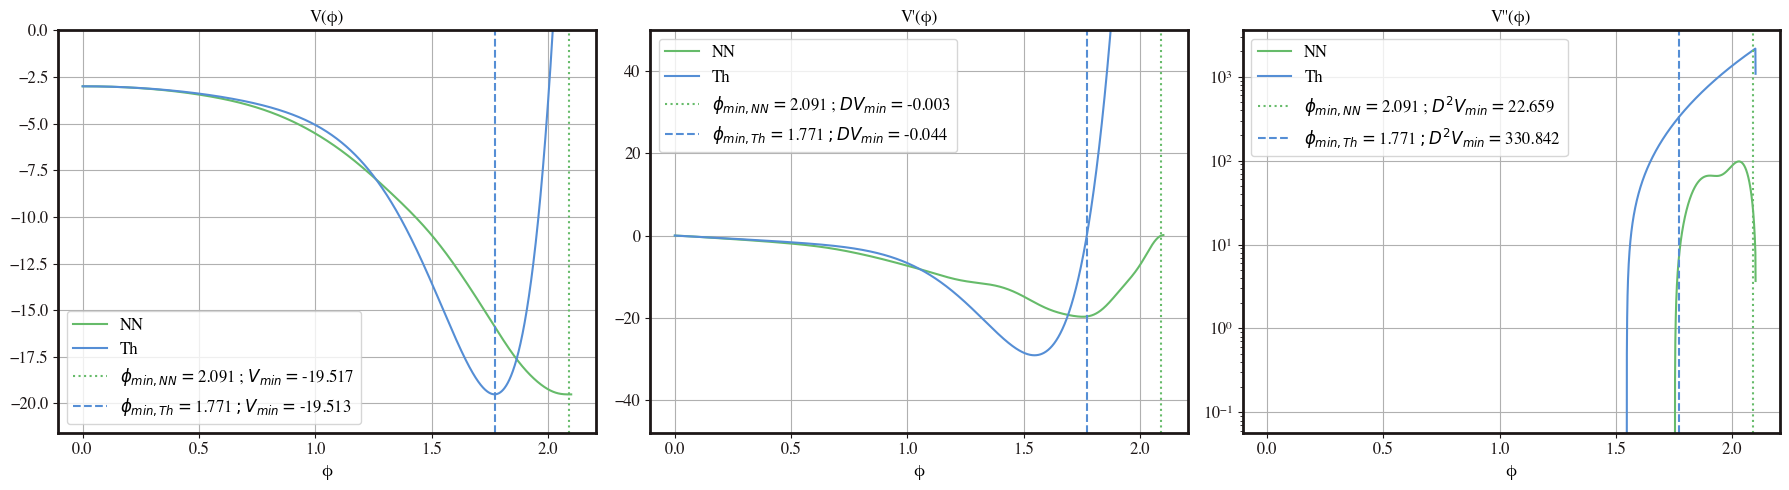

In [3]:
phi = torch.linspace(0,2.1, 5000).reshape(-1,1)
V_nn = c.V(phi)

idx_min = np.argmin(V_nn.detach().numpy())
phi_min = phi[idx_min].detach().numpy()


V_th = V_or(phi.detach().numpy(), phim = 0.8)
idx_min_th = np.argmin(V_th)


DV_th = np.gradient(V_th.reshape(-1,), phi.detach().numpy().reshape(-1,))
DDV_th = np.gradient(DV_th.reshape(-1,), phi.detach().numpy().reshape(-1,))

DV_nn = np.gradient(V_nn.detach().numpy().reshape(-1,), phi.detach().numpy().reshape(-1,))
DDV_nn = np.gradient(DV_nn.reshape(-1,), phi.detach().numpy().reshape(-1,))

Vmin_th = V_th[idx_min_th]
DVmin_th = DV_th[idx_min_th]
DDVmin_th = DDV_th[idx_min_th]

Vmin_nn = V_nn.detach().numpy()[idx_min]
DVmin_nn = DV_nn[idx_min]
DDVmin_nn = DDV_nn[idx_min]


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

phi_np = phi.detach().numpy().reshape(-1,)
Vnn_np = V_nn.detach().numpy().reshape(-1,)

# --- 1) Potential ---
axes[0].plot(phi_np, Vnn_np, label='NN')
axes[0].plot(phi_np, V_th, label='Th')
axes[0].axvline(phi_min, linestyle='dotted', color='C0', label =r'$\phi_{min,NN}=$'+fr'{phi_min[0]:.3f}'+ r' ; $V_{min}=$'+rf'{Vmin_nn[0]:.3f}')
axes[0].axvline(phi_np[idx_min_th], linestyle='dashed', color='C1', label =r'$\phi_{min,Th}=$'+fr'{phi_np[idx_min_th]:.3f}'+ r' $; V_{min}=$'+rf'{Vmin_th[0]:.3f}')
axes[0].set_ylim(top=0)
axes[0].set_title('V(φ)')
axes[0].legend()
axes[0].grid()

# --- 2) First derivative ---
axes[1].plot(phi_np, DV_nn, label='NN')
axes[1].plot(phi_np, DV_th, label='Th')
axes[1].axvline(phi_min, linestyle='dotted', color='C0', label =r'$\phi_{min,NN}=$'+fr'{phi_min[0]:.3f}'+ r' ; $DV_{min}=$'+rf'{DVmin_nn:.3f}')
axes[1].axvline(phi_np[idx_min_th], linestyle='dashed', color='C1', label =r'$\phi_{min,Th}=$'+fr'{phi_np[idx_min_th]:.3f}'+ r' $; DV_{min}=$'+rf'{DVmin_th:.3f}')
axes[1].set_ylim(top=50)
axes[1].set_title("V'(φ)")
axes[1].legend()
axes[1].grid()

# --- 3) Second derivative ---
axes[2].plot(phi_np, DDV_nn, label='NN')
axes[2].plot(phi_np, DDV_th, label='Th')
axes[2].axvline(phi_min, linestyle='dotted', color='C0', label =r'$\phi_{min,NN}=$'+fr'{phi_min[0]:.3f}'+ r' ; $D^2V_{min}=$'+rf'{DDVmin_nn:.3f}')
axes[2].axvline(phi_np[idx_min_th], linestyle='dashed', color='C1', label =r'$\phi_{min,Th}=$'+fr'{phi_np[idx_min_th]:.3f}'+ r' $; D^2V_{min}=$'+rf'{DDVmin_th:.3f}')
axes[2].set_yscale('log')
axes[2].set_title("V''(φ)")
axes[2].legend()
axes[2].grid()

for ax in axes:
    ax.set_xlabel('φ')

plt.tight_layout()
plt.show()


In [6]:
# phi = torch.linspace(0,2.1, 5000).reshape(-1,1)
# V_nn = c.V(phi)

# idx_min = np.argmin(V_nn.detach().numpy())
# phi_min = phi[idx_min].detach().numpy()


# V_th = V_or(phi.detach().numpy(), phim = 0.8)
# idx_min_th = np.argmin(V_th)

# plt.plot(phi.detach().numpy(), V_nn.detach().numpy(), label = 'NN')
# plt.plot(phi.detach().numpy(), V_th, label = 'Th')
# plt.axvline(phi_min, linestyle='dotted', color = 'C0')
# plt.axvline(phi.detach().numpy()[idx_min_th], linestyle='dashed',color = 'C1')
# plt.ylim(top=0)
# plt.legend()
# plt.show()

# print(V_th.shape, phi.detach().numpy().shape)


# DV_th = np.gradient(V_th.reshape(-1,), phi.detach().numpy().reshape(-1,))
# DDV_th = np.gradient(DV_th.reshape(-1,), phi.detach().numpy().reshape(-1,))

# DV_nn = np.gradient(V_nn.detach().numpy().reshape(-1,), phi.detach().numpy().reshape(-1,))
# DDV_nn = np.gradient(DV_nn.reshape(-1,), phi.detach().numpy().reshape(-1,))

# Vmin_th = V_th[idx_min_th]
# DVmin_th = DV_th[idx_min_th]
# DDVmin_th = DDV_th[idx_min_th]

# Vmin_nn = V_nn.detach().numpy()[idx_min]
# DVmin_nn = DV_nn[idx_min]
# DDVmin_nn = DDV_nn[idx_min]


# print('Vmin_th:', Vmin_th, 'Vmin_nn:', Vmin_nn, f'diff={(Vmin_th - Vmin_nn)}')
# print('DVmin_th:', DVmin_th, 'DVmin_nn:', DVmin_nn,  f'diff={(DVmin_th -DVmin_nn)}')
# print('DDVmin_th:', DDVmin_th, 'DDVmin_nn:', DDVmin_nn,  f'diff={(DDVmin_th - DDVmin_nn)}')


In [7]:
# plt.plot(phi.detach().numpy(), DV_nn, label = 'NN')
# plt.plot(phi.detach().numpy(), DV_th, label = 'Th')
# plt.axvline(phi_min, linestyle='dotted', color = 'C0')
# plt.axvline(phi.detach().numpy()[idx_min_th], linestyle='dashed',color = 'C1')
# plt.grid()
# plt.legend()
# plt.ylim(top=50)

# plt.show()

# plt.plot(phi.detach().numpy(), DDV_nn, label = 'NN')
# plt.plot(phi.detach().numpy(), DDV_th, label = 'Th')
# plt.axvline(phi_min, linestyle='dotted', color = 'C0')
# plt.axvline(phi.detach().numpy()[idx_min_th], linestyle='dashed',color = 'C1')
# plt.legend()
# # plt.ylim(top=500)
# plt.yscale('log')
# plt.grid()

# plt.show()

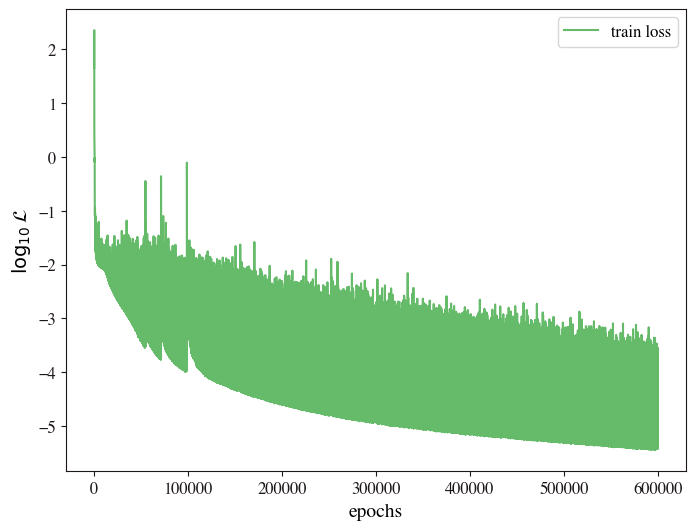

Min loss:  3.545278472668745e-06


In [4]:
c.plot_loss(save_fig=False)


In [10]:
c.plot_separate_losses_new(save_fig=False)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [6]:
c.solver.metrics_history

{'train_loss': [45.37324197058715,
  37.95870179353838,
  31.145274608528577,
  24.683444211214287,
  18.60656924806872,
  13.394236569906102,
  9.792802211803524,
  8.31912693789092,
  8.74072852976574,
  9.880199730153603,
  10.290499200122385,
  9.723949045871397,
  8.548385034904815,
  7.272778811686856,
  6.300828674381064,
  5.724534277775131,
  5.574053793364804,
  5.730079298404759,
  5.966412571142581,
  6.135630586364407,
  6.121215096818532,
  5.923048854887165,
  5.555521514705535,
  5.14456353666282,
  4.780234813159717,
  4.4792333696415385,
  4.327104879872071,
  4.271822332174561,
  4.249883255214809,
  4.2534828501921496,
  4.171218448469927,
  4.018981109106384,
  3.8510507782203254,
  3.699275737936388,
  3.430354246454525,
  3.3758075425409215,
  3.215830432805254,
  3.162141980577729,
  227.83999949355282,
  3.5115760986779483,
  3.4591940607210154,
  3.395998327015434,
  3.3488425128266823,
  3.3406869618237076,
  3.34419237298838,
  3.3499215516244614,
  3.357777

In [9]:
loss = c.solver.metrics_history
tot_loss = loss['train_loss']
past_epochs = None

if past_epochs is None:
    past_epochs = len(tot_loss)

DE_loss = np.array(loss['r2_loss'])

if 'V_min_addloss' in loss.keys():
    Vmin_addloss = np.array(loss['V_min_addloss'])
if 'DV_DDV_min_addloss' in loss.keys():
    DVDDV_min_addloss = np.array(loss['DV_DDV_min_addloss'])
if 'V0_addloss' in loss.keys():
    V0_addloss = np.array(loss['DV_DDV_min_addloss'])

print(Vmin_addloss)


min_tot_loss = [0.0]
min_DE_loss = [0.0]
min_Vmin_addloss = [0.0]
min_DVDDV_min_addloss = [0.0]
min_V0_addloss = [0.0]

# Initialize min-tracking for all loss arrays
for i in range(1, len(tot_loss)):
    # --- total loss ---
    if i == 0:
        min_tot_loss.append(tot_loss[i])
        min_DE_loss.append(DE_loss[i])
        # min_above_phi_c_addloss.append(above_phi_c_addloss[i])
        # min_pH_ordering_addloss.append(pH_ordering_addloss[i])
        min_Vmin_addloss.append(Vmin_addloss[i])
        min_DVDDV_min_addloss.append(DVDDV_min_addloss[i])
        min_V0_addloss.append(V0_addloss[i])
    else:
        # total loss
        if tot_loss[i] < min_tot_loss[-1]:
            m_tot = tot_loss[i]
        else:
            m_tot = min_tot_loss[-1]
        min_tot_loss.append(m_tot)

        # DE loss
        if DE_loss[i] < min_DE_loss[-1]:
            m_DE = DE_loss[i]
        else:
            m_DE = min_DE_loss[-1]
        min_DE_loss.append(m_DE)

        # # above φ_c addloss
        # if above_phi_c_addloss[i] < min_above_phi_c_addloss[-1]:
        #     m_above = above_phi_c_addloss[i]
        # else:
        #     m_above = min_above_phi_c_addloss[-1]
        # min_above_phi_c_addloss.append(m_above)

        # # φ_H-ordering addloss
        # if pH_ordering_addloss[i] < min_pH_ordering_addloss[-1]:
        #     m_pH = pH_ordering_addloss[i]
        # else:
        #     m_pH = min_pH_ordering_addloss[-1]
        # min_pH_ordering_addloss.append(m_pH)

        # Vmin addloss
        if Vmin_addloss[i] < min_Vmin_addloss[-1]:
            m_Vmin = Vmin_addloss[i]
        else:
            m_Vmin = min_Vmin_addloss[-1]
        min_Vmin_addloss.append(m_Vmin)

        # V0 addloss
        if V0_addloss[i] < min_V0_addloss[-1]:
            m_V0 = Vmin_addloss[i]
        else:
            m_V0 = min_V0_addloss[-1]
        min_V0_addloss.append(m_V0)

        if DVDDV_min_addloss[i] < min_DVDDV_min_addloss[-1]:
            m_DVDDV = DVDDV_min_addloss[i]
        else:
            m_DVDDV = min_DVDDV_min_addloss[-1]
        min_DVDDV_min_addloss.append(m_DVDDV)


fig = plt.figure(figsize=(6,6))
plt.plot(min_tot_loss[-past_epochs:], label='tot loss', alpha=1.0)
plt.plot(min_DE_loss[-past_epochs:], label='DE loss', alpha=1)


if c.solver.force_V_min_coef != 0:
    plt.plot(min_Vmin_addloss[-past_epochs:], label=r'Vmin addloss', alpha=1, color='purple')

if c.solver.force_DV_DDV_min_coef != 0:
    plt.plot(min_DVDDV_min_addloss[-past_epochs:], label=r'$\partial^{1,2}$ Vmin addloss', alpha=1, color='red')

if c.solver.force_V0_coef != 0:
    plt.plot(min_V0_addloss[-past_epochs:], label=r'V(0) addloss', alpha=1, color='blue')


plt.yscale('log')
plt.legend(loc=(1.1, 0.5))

plt.show()
plt.show()

    

[]


IndexError: index 1 is out of bounds for axis 0 with size 0

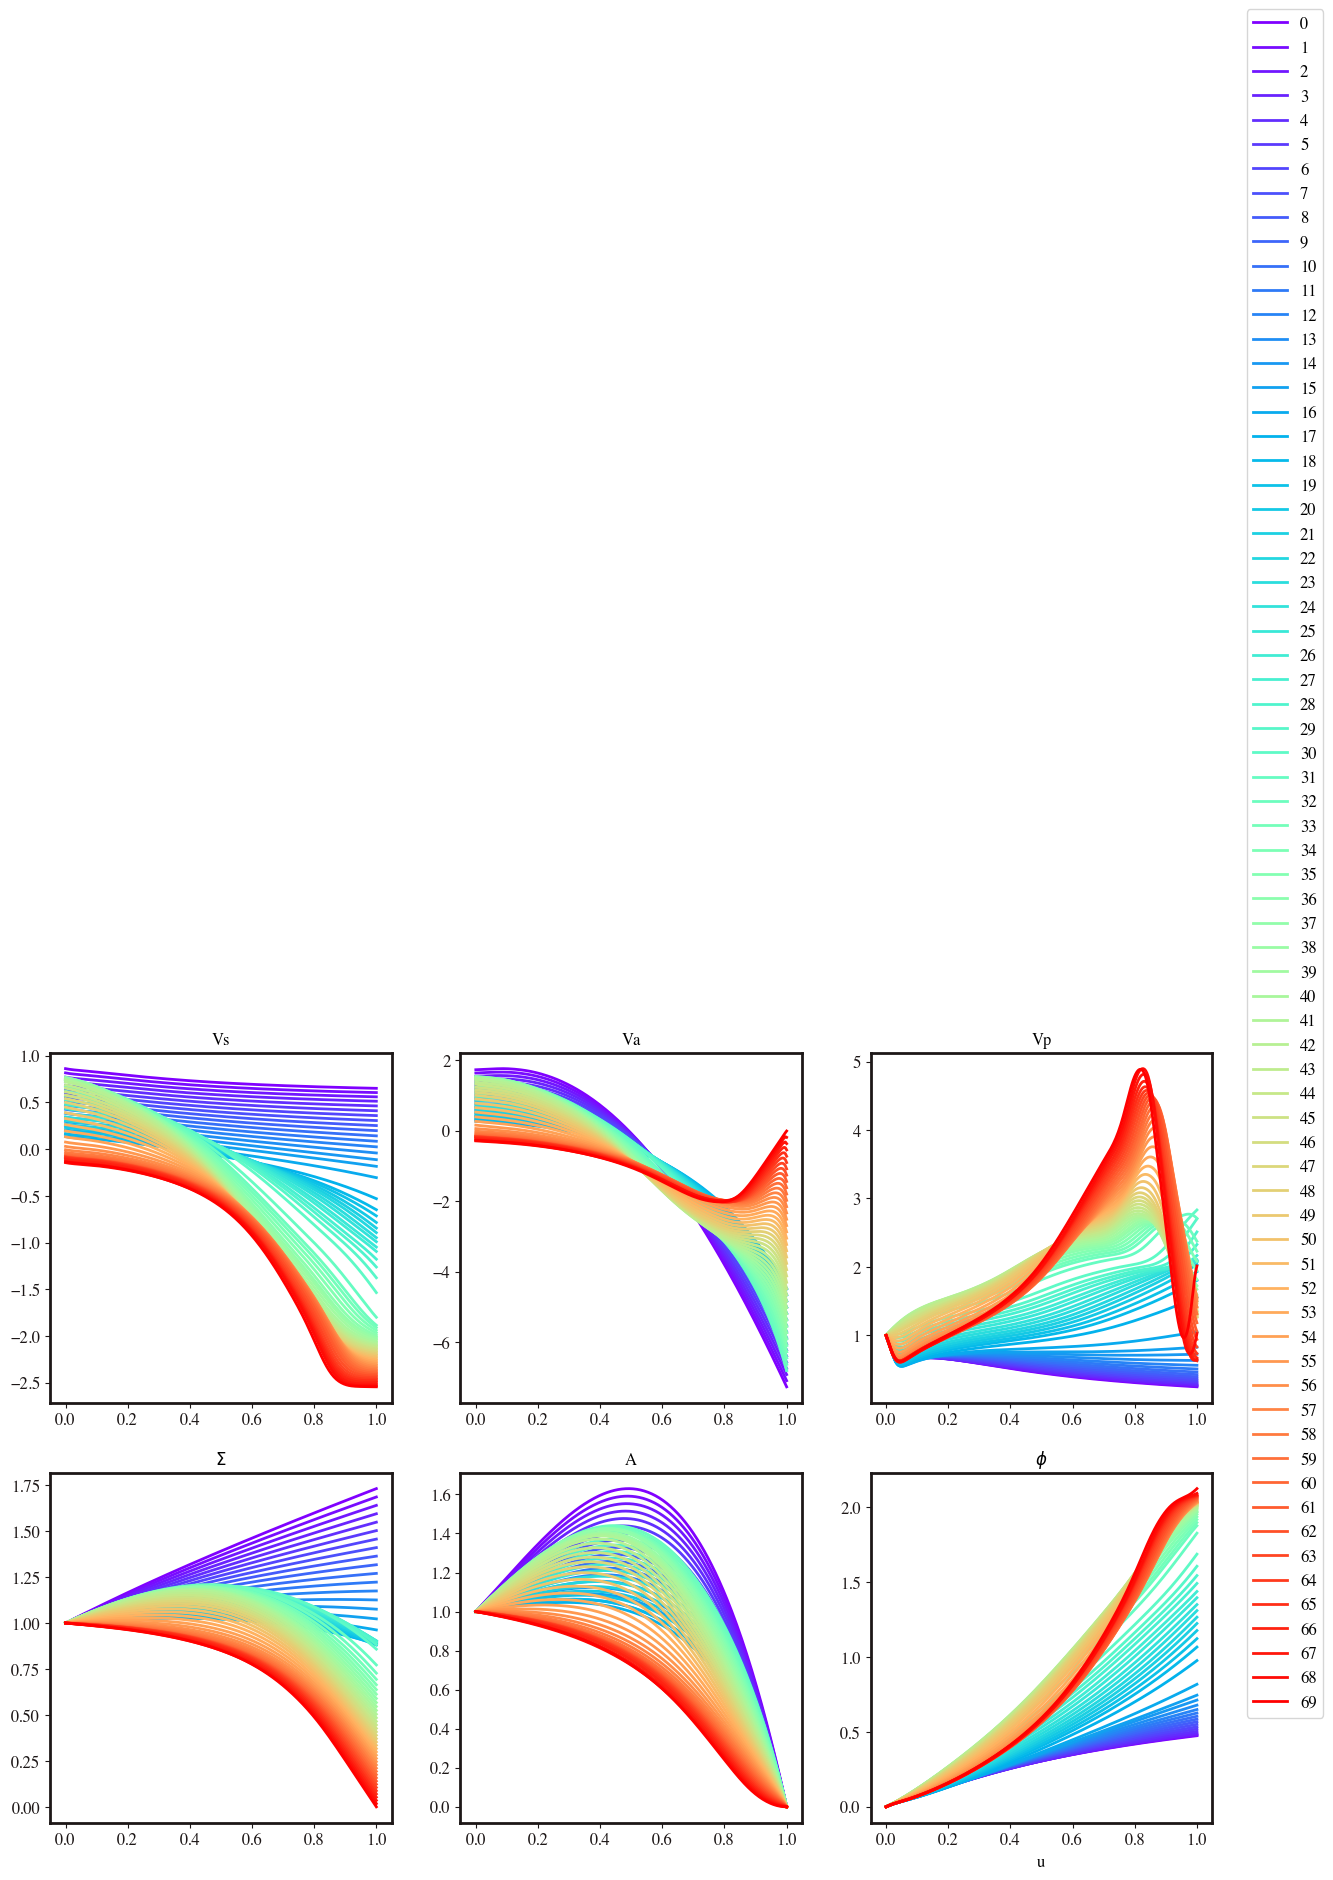

In [72]:
c.plot_solutions(save_fig =False)


In [ ]:
c.plot_residuals_in_u_color(save_fig=False)
c.plot_colored_sofT(save_fig=False, colormap='rainbow')
c.compute_relative_error(n_pts = 1000, phim_param = phim_param[0], save_fig = True)


In [2]:
c.solver.metrics_history

{'train_loss': [365.1317817182517,
  354.1783164683109,
  352.19266112585063,
  336.4844231151143],
 'valid_loss': [],
 'r2_loss': [52.586491965640214,
  43.100776194518005,
  34.760009537744054,
  26.97528771406917],
 'phi_max': [0.06069794827591045,
  0.10453033927283088,
  0.1546433639189277,
  0.144546033183677],
 'add_loss': [312.5452897526115,
  311.0775402737929,
  317.4326515881066,
  309.5091354010451],
 'monotonic_phi_add_loss': [],
 'V_min_addloss': [191.5174031639832,
  191.35941283726282,
  191.20687437467387,
  191.09949443943938],
 'DV_DDV_min_addloss': [111.84944687142912,
  110.6536542832968,
  117.23894447542297,
  109.43882666856737],
 'V0_addloss': [9.178439717199206,
  9.0644731532333,
  8.986832738009735,
  8.97081429303835]}